In [2]:
import numpy as np
import pandas as pd
from numpy import random
import os
os.getcwd()     #get current working directory
os.chdir("/content/drive/MyDrive")
os.getcwd
import scipy
from scipy import stats
from scipy.stats import norm,t
from collections import Counter
from scipy.stats import binom
from scipy.stats import poisson
from scipy.stats import expon
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import pylab
from pylab import legend
from pylab import plot,show,title,xlabel,ylabel


In [3]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
import sklearn
from sklearn.model_selection import train_test_split

In [4]:
#import dataset
df=pd.read_excel('CDAC_DataBook (1).xlsx',sheet_name='faithful')

In [5]:
df.head()

,eruptions,waiting
0,3.600,79
1,1.800,54
2,3.333,74
3,2.283,62
4,4.533,85


In [6]:
# waithing is the predictor

In [7]:
# erupption is the response

In [8]:
scipy.stats.pearsonr(df.eruptions, df.waiting)

PearsonRResult(statistic=np.float64(0.9008111683218132), pvalue=np.float64(8.129958506615525e-100))

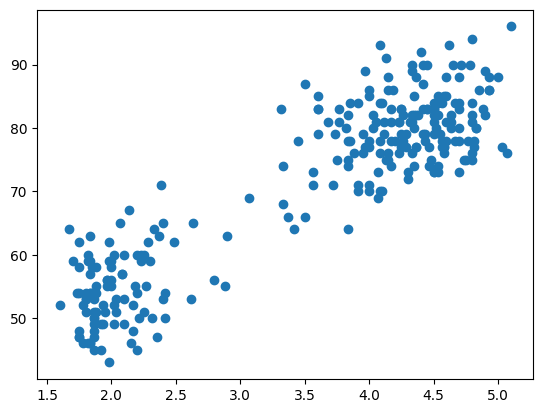

In [9]:
plt.scatter(df.eruptions,df.waiting)

In [10]:
#split for train test
x_train, x_test, y_train, y_test = train_test_split(df.waiting,df.eruptions, test_size=0.3)

In [11]:
x_train.head()

,waiting
224,78
18,52
223,75
26,55
219,76


In [12]:
y_train.head()

,eruptions
224,4.000
18,1.600
223,4.483
26,1.967
219,4.150


In [13]:
df.shape

(272, 2)

In [14]:
270*0.7

189.0

In [15]:
x_train.shape

(190,)

In [16]:
x_train, x_test, y_train, y_test = train_test_split(df.waiting,df.eruptions, test_size=0.3,random_state=20)

In [17]:
x_train.head()

,waiting
182,83
248,67
50,75
209,83
200,60


In [18]:
#add constant here
x_train = sm.add_constant(x_train, prepend=False)
x_test = sm.add_constant(x_test, prepend=False)

In [19]:
# prepare the model
mod1 = sm.OLS(y_train,x_train).fit()

M -- coef column

C --

R squared -- coefficient of determination

it represents the percentage of variation in dataset which is explained by the model

p >[t] ----these are p value


In [20]:
print(mod1.summary())         # eruption =0.0782 * waiting - 2.08

                            OLS Regression Results                            
Dep. Variable:              eruptions   R-squared:                       0.804
Model:                            OLS   Adj. R-squared:                  0.803
Method:                 Least Squares   F-statistic:                     771.1
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           1.94e-68
Time:                        11:08:13   Log-Likelihood:                -140.85
No. Observations:                 190   AIC:                             285.7
Df Residuals:                     188   BIC:                             292.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
waiting        0.0782      0.003     27.768      0.0

In [21]:
# m= 0.0782
# c=-2.0814
# p value =p>[t]

0.0782/0.003      #t


26.066666666666666

In [22]:
-2.0814/0.203     #t

-10.25320197044335

In [23]:
# prediction

mydata = pd.DataFrame([[80,1],[90,1],[100,1]], columns = x_train.columns)
mypreds = mod1.predict(mydata)

In [24]:
mypreds

,0
0,4.176827
1,4.959109
2,5.741392


In [25]:
y_preds=mod1.predict(x_train)

In [26]:
y_preds.head()

,0
182,4.411512
248,3.159859
50,3.785686
209,4.411512
200,2.612262


In [27]:
y_train.head()    # this error called as residual

,eruptions
182,4.250
248,2.133
50,4.800
209,4.500
200,2.100


In [28]:
residuals = y_train - y_preds
residuals.head()

,0
182,-0.161512
248,-1.026859
50,1.014314
209,0.088488
200,-0.512262


In [29]:
sum(residuals)

5.684341886080801e-13

(array([ 5.,  9., 18., 30., 25., 36., 30., 20., 13.,  4.]),
 array([-1.25817472, -1.01204863, -0.76592254, -0.51979646, -0.27367037,
        -0.02754428,  0.21858181,  0.4647079 ,  0.71083398,  0.95696007,
         1.20308616]),
 <BarContainer object of 10 artists>)

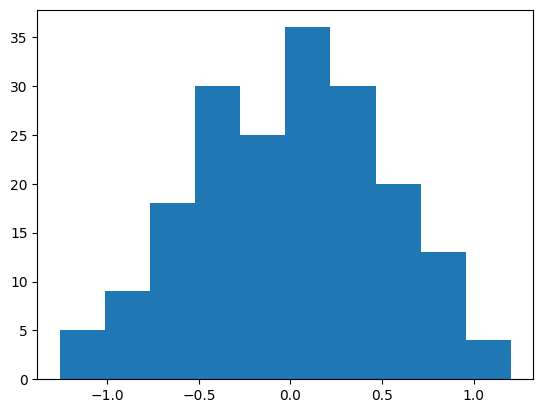

In [30]:
plt.hist(residuals)

In [31]:
#sum square of error >>> SSE
SSE=sum(residuals**2)   # unexplained variation

In [32]:
SSE

48.99679457123917

In [33]:
#SUM SQUARE OF TOTAL VARIATION >> SST
SST = sum((y_train - np.mean(y_train))**2)


In [34]:
SST

249.95112065263157

In [35]:
#Sum square of regression OR explained variation >> SSR
SSR =SST - SSE

In [36]:
SSR

200.9543260813924

In [37]:
# fraction of toatl variation explained by the model
# this ratio is the same as R squared

SSR/SST       # >> R Squared value ... that can be calculataed like that


0.803974495320098

In [38]:
y_train.shape

(190,)

In [39]:
#total no of values = 190
# total degree of freedom = 189
# dof for regresssion model = 2-1 =1
# dof for eror or residual =189 -1 =188

#((SSR)/(dof for regresssion model))/(SSE/(dof for eror or residual))

F= ((SSR)/(1))/(SSE/(188))


In [40]:
F     # F statsistics

771.0588750529828

In [41]:
# prob (F statsistics) >> p value.   .. it will come from the F statsistics value

In [42]:
from scipy.stats import f

In [43]:
p_value = 1 - f.cdf(F,1,188)

In [44]:
p_value

np.float64(1.1102230246251565e-16)

# **SKLEARN**

In [45]:
from sklearn.linear_model import LinearRegression

In [47]:
regr1=LinearRegression()

In [50]:

x_train, x_test, y_train, y_test = train_test_split(df.waiting,df.eruptions, test_size=0.3, random_state=20)
x_train = np.array(x_train).reshape(-1,1)
y_train = np.array(y_train).reshape(-1,1)



In [51]:
 regr1.fit(x_train,y_train)   # create the model

LinearRegression()

In [56]:
regr1.coef_     # values for the coefficient

array([[0.07822826]])

In [53]:
regr1.intercept_            #values for the intercept

array([-2.08143394])

In [54]:
regr1.score(x_train,y_train)          #R2 (based on the training set)

0.803974495320098

In [55]:
y_preds=regr1.predict(x_train)          #making predictions

In [57]:
from sklearn.metrics import mean_squared_error

In [63]:
# Calculate the mean squared error between y_pred and y_train

mse1 = mean_squared_error(y_preds,y_train)

In [64]:
mse1

0.2578778661644167

In [65]:
SSE

48.99679457123917

In [69]:
SSE/190

0.2578778661644167

In [66]:
from sklearn.model_selection import cross_val_score

In [67]:
cross_val_score(regr1,x_train,y_train,scoring='neg_mean_squared_error',cv=5)        #validation

array([-0.27359473, -0.24925173, -0.25445376, -0.25548319, -0.27051377])

In [71]:
df=pd.read_excel('CDAC_DataBook (1).xlsx',sheet_name='stackloss')

In [72]:
df.head(

)

,AirFlow,WaterTemp,AcidConc,StackLoss
0,80,27,89,42
1,80,27,88,37
2,75,25,90,37
3,62,24,87,28
4,62,22,87,18


In [ ]:
pil.

In [77]:
scipy.stats.pearsonr(df.AirFlow, df.StackLoss)

PearsonRResult(statistic=np.float64(0.9196634529058556), pvalue=np.float64(3.774295990666341e-09))

In [78]:
# Split for train-test
x_train, x_test, y_train, y_test = train_test_split(df.drop('StackLoss', axis=1),df.StackLoss, test_size=0.1, random_state=20)

In [79]:
# Add constant term
x_train = sm.add_constant(x_train, prepend=False)
x_test = sm.add_constant(x_test, prepend=False)

In [80]:
# Prepare the model
mod1 = sm.OLS(y_train,x_train).fit()

In [81]:
print(mod1.summary())

                            OLS Regression Results                            
Dep. Variable:              StackLoss   R-squared:                       0.908
Model:                            OLS   Adj. R-squared:                  0.888
Method:                 Least Squares   F-statistic:                     46.11
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           1.67e-07
Time:                        12:17:11   Log-Likelihood:                -45.877
No. Observations:                  18   AIC:                             99.75
Df Residuals:                      14   BIC:                             103.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
AirFlow        0.7001      0.152      4.592      0.0